# Exploración del dataset MetroPT-3

**Trabajo Fin de Máster**

Diseño e implementación de un pipeline de ingeniería de datos para mantenimiento predictivo utilizando el dataset MetroPT-3

# 1. Objetivo
El objetivo de este notebook es realizar un análisis exploratorio del dataset MetroPT-3 con el fin de comprender su estructura, calidad y características antes del diseño e implementación del pipeline de ingeniería de datos.

Los resultados obtenidos permitirán:

comprender la estructura del conjunto de datos;
evaluar la calidad de los datos;
identificar posibles transformaciones necesarias;
justificar las decisiones de diseño del pipeline.

# 2. Importación de librearías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

plt.rcParams["figure.figsize"] = (12,5)

# 3. Carga del dataset

In [2]:

DATA_PATH = Path("../data/raw/MetroPT3(AirCompressor).csv")

print(DATA_PATH)
print(DATA_PATH.exists())

../data/raw/MetroPT3(AirCompressor).csv
True


In [3]:
df = pd.read_csv(DATA_PATH)

# 3. Primera inspección

In [4]:
pd.DataFrame({
    "Métrica":[
        "Número de registros",
        "Número de columnas"
    ],
    "Valor":[
        df.shape[0],
        df.shape[1]
    ]
})

,Métrica,Valor
0,Número de registros,1516948
1,Número de columnas,17


**Primeras observaciones:**

In [5]:
df.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


**Interpretación**

Durante la inspección inicial se observa que:
+ existe una columna denominada Unnamed: 0;
+ el timestamp se encuentra almacenado como texto;
+ existen sensores analógicos;
+ existen variables binarias.

La estructura coincide con la documentación oficial del dataset.

# 4. Calidad de los datos

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  str    
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1516948 non-

**Interpretación**

El análisis muestra que:

+ existen 17 columnas;
+ no hay valores nulos;
+ la columna temporal se encuentra almacenada como texto;
+ la memoria utilizada es aproximadamente 197 MB.

**Valores nulos**

In [7]:
df.isnull().sum()

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

**Filas duplicadas**

In [8]:
df.duplicated().sum()

np.int64(0)

# 5. Estadísticas descriptivas

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1516948.0,7.584735e+06,4.379053e+06,0.000,3792367.500,7584735.000,1.137710e+07,1.516947e+07
TP2,1516948.0,1.367826e+00,3.250930e+00,-0.032,-0.014,-0.012,-1.000000e-02,1.067600e+01
TP3,1516948.0,8.984611e+00,6.390951e-01,0.730,8.492,8.960,9.492000e+00,1.030200e+01
H1,1516948.0,7.568155e+00,3.333200e+00,-0.036,8.254,8.784,9.374000e+00,1.028800e+01
DV_pressure,1516948.0,5.595619e-02,3.824015e-01,-0.032,-0.022,-0.020,-1.800000e-02,9.844000e+00
Reservoirs,1516948.0,8.985233e+00,6.383070e-01,0.712,8.494,8.960,9.492000e+00,1.030000e+01
Oil_temperature,1516948.0,6.264418e+01,6.516261e+00,15.400,57.775,62.700,6.725000e+01,8.905000e+01
Motor_current,1516948.0,2.050171e+00,2.302053e+00,0.020,0.040,0.045,3.807500e+00,9.295000e+00
COMP,1516948.0,8.369568e-01,3.694052e-01,0.000,1.000,1.000,1.000000e+00,1.000000e+00
DV_eletric,1516948.0,1.606106e-01,3.671716e-01,0.000,0.000,0.000,0.000000e+00,1.000000e+00


**Interpretación**

Del análisis estadístico se desprende que:

+ las variables continuas presentan rangos compatibles con magnitudes físicas;
+ las variables binarias únicamente contienen valores 0 y 1;
+ algunas señales permanecen activas durante la mayor parte del tiempo;
+ la columna Unnamed: 0 parece representar un índice y no una variable física.

# 6. Análisis temporal

**Conversión del timestamp**

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

**Verificación**

In [11]:
df["timestamp"].dtype

dtype('<M8[us]')

**Rango temporal**

In [12]:
print(f"Inicio: {df['timestamp'].min()}")
print(f"Fin: {df['timestamp'].max()}")

Inicio: 2020-02-01 00:00:00
Fin: 2020-09-01 03:59:50


El conjunto de datos cubre aproximadamente siete meses de funcionamiento del sistema monitorizado.

**Duración**

In [13]:
duracion = df["timestamp"].max() - df["timestamp"].min()

print(duracion)

213 days 03:59:50


**Intervalos temporales**

In [14]:
intervalos = df["timestamp"].diff().dropna()

intervalos.value_counts(normalize=True).head(10)*100

timestamp
0 days 00:00:10    88.171901
0 days 00:00:09     8.456261
0 days 00:00:12     2.526192
0 days 00:00:13     0.526584
0 days 00:00:11     0.294737
0 days 00:00:21     0.000659
0 days 00:00:19     0.000330
0 days 00:00:22     0.000264
0 days 00:00:20     0.000198
0 days 00:00:17     0.000198
Name: proportion, dtype: float64

**Visualización**

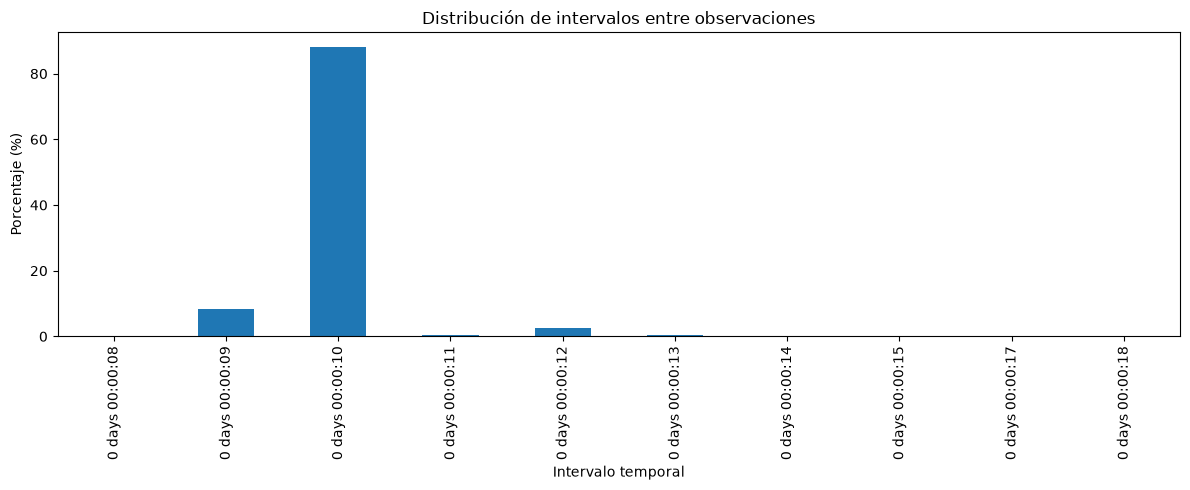

In [15]:
(intervalos.value_counts(normalize=True)
           .sort_index()
           .head(10)
           .mul(100)
           .plot(kind="bar"))

plt.ylabel("Porcentaje (%)")
plt.xlabel("Intervalo temporal")
plt.title("Distribución de intervalos entre observaciones")
plt.tight_layout()

# 7. Conclusiones
El análisis exploratorio realizado permite extraer las siguientes conclusiones:

+ El dataset contiene 1.516.948 registros y 17 variables.
+ No se detectan valores nulos ni registros duplicados.
+ La columna temporal deberá transformarse a tipo datetime.
+ La columna Unnamed: 0 no parece aportar información relevante para el análisis.
+ Las variables binarias presentan una codificación consistente.
+ El muestreo presenta un intervalo nominal de 10 segundos, aunque existen pequeñas variaciones y algunas interrupciones puntuales.
+ Los resultados obtenidos servirán para definir las etapas de ingesta, validación y transformación del pipeline de ingeniería de datos.